# 02 · Build Dataset Empresa V4 - Features para Dataset Maestro

Este notebook construye **features de empresa** para alimentar el **dataset maestro**.

## Enfoque correcto

Este notebook **no entrena un modelo de empresa**.  
El dataset de empresa se usa como una capa intermedia de feature engineering.

Flujo:

```text
Datos empresa
    ↓
Vínculos empresa-obra
    ↓
Features agregadas por obra
    ↓
Dataset maestro
    ↓
Modelo final
```

## Salida principal

```text
data/processed/dataset_empresa_v4_features_por_obra.parquet
```

Este archivo debe ser usado por el notebook de construcción del dataset maestro.

## Salidas auxiliares

```text
data/processed/dataset_empresa_v4_vinculo_auditoria.parquet
data/processed/dataset_empresa_v4_unico_auditoria.parquet
data/processed/dataset_empresa_v4_meta.json
```

Las salidas de auditoría conservan RUC y nombres solo para trazabilidad.  
**No deben usarse directamente para entrenamiento.**


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

BASE = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")

DATA_EXT = BASE / "data" / "external" / "empresa"
DATA_PROC = BASE / "data" / "processed"
REPORTS = BASE / "reports" / "figures"

DATA_PROC.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("DATA_EXT:", DATA_EXT)
print("DATA_PROC:", DATA_PROC)


BASE: C:\IA_Investigacion\Deteccion_Corrupcion
DATA_EXT: C:\IA_Investigacion\Deteccion_Corrupcion\data\external\empresa
DATA_PROC: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed


## 1. Utilidades

In [2]:
def read_csv_robust(path: Path) -> pd.DataFrame:
    """Lee CSV probando codificaciones frecuentes."""
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_error = e

    raise RuntimeError(f"No se pudo leer {path.name}: {last_error}")


def clean_text_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )


def normalize_colnames(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def find_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols_upper = {c.upper(): c for c in df.columns}
    for cand in candidates:
        if cand.upper() in cols_upper:
            return cols_upper[cand.upper()]
    return None


def normalize_ruc_column(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza variantes de RUC principal a CODIGO_RUC si aplica."""
    df = df.copy()

    candidates = [
        "CODIGO_RUC",
        "RUC",
        "RUC_EMPRESA",
        "RUC_GANADOR",
        "CODIGO_RUC_GANADOR",
        "CODIGO_RUC_PARTICIPANTE",
        "RUC_PARTICIPANTE",
    ]

    col = find_col(df, candidates)

    if col is not None and col != "CODIGO_RUC":
        df = df.rename(columns={col: "CODIGO_RUC"})

    if "CODIGO_RUC" in df.columns:
        df["CODIGO_RUC"] = clean_text_series(df["CODIGO_RUC"])

    return df


def normalize_codigo_obra(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza variantes de código de obra a CODIGO_OBRA si aplica."""
    df = df.copy()

    candidates = [
        "CODIGO_OBRA",
        "CODIGO_UNICO",
        "COD_UNICO",
        "ID_OBRA",
        "IDENTIFICADOR_OBRA",
    ]

    col = find_col(df, candidates)

    if col is not None and col != "CODIGO_OBRA":
        df = df.rename(columns={col: "CODIGO_OBRA"})

    if "CODIGO_OBRA" in df.columns:
        df["CODIGO_OBRA"] = clean_text_series(df["CODIGO_OBRA"])

    return df


def flag_from_text_or_number(s: pd.Series) -> pd.Series:
    """Convierte señales tipo SI/NO, TRUE/FALSE o 1/0 a binario."""
    if pd.api.types.is_numeric_dtype(s):
        return (s.fillna(0).astype(float) > 0).astype(int)

    x = s.astype(str).str.upper().str.strip()

    positives = [
        "SI",
        "SÍ",
        "YES",
        "TRUE",
        "1",
        "ACTIVO",
        "SANCIONADO",
        "INHABILITADO",
        "OBSERVADO",
    ]

    return x.isin(positives).astype(int)


def existing_cols(df: pd.DataFrame, cols: list[str]) -> list[str]:
    return [c for c in cols if c in df.columns]


def safe_div(num, den):
    return num / (den + 1e-9)


## 2. Carga de archivos de empresa

In [3]:
empresa_files = {
    "1A": "DS_DASH_Empresa_1A.csv",
    "1B": "DS_DASH_Empresa_1B.csv",
    "2A": "DS_DASH_Empresa_2A.csv",
    "2B": "DS_DASH_Empresa_2B.csv",
    "2C": "DS_DASH_Empresa_2C.csv",
}

tablas = {}

for key, filename in empresa_files.items():
    path = DATA_EXT / filename

    if not path.exists():
        print(f"[WARN] No existe: {path}")
        tablas[key] = pd.DataFrame()
        continue

    df_tmp = read_csv_robust(path)
    df_tmp = normalize_colnames(df_tmp)
    df_tmp = normalize_ruc_column(df_tmp)
    df_tmp = normalize_codigo_obra(df_tmp)

    tablas[key] = df_tmp

    print(f"{key} | {filename} | shape={df_tmp.shape}")
    print(df_tmp.columns.tolist())
    print("-" * 90)


1A | DS_DASH_Empresa_1A.csv | shape=(553, 9)
['CODIGO_OBRA', 'CODIGO_RUC', 'NOMBRE_EMPRESA', 'EsConsorcio', 'SANCIONADAS_TCE', 'INHABILITADAS_PJ', 'SANCIONADAS_RNP', 'INHABILITADAS_RNP', 'IMPEDIDAS_RNP']
------------------------------------------------------------------------------------------
1B | DS_DASH_Empresa_1B.csv | shape=(2148, 5)
['CODIGO_OBRA', 'CODIGO_RUC', 'NOMBRE_EMPRESA', 'DNI_REPRESENTANTE_LEGAL', 'NOMBRE_REPRESENTANTE_LEGAL']
------------------------------------------------------------------------------------------
2A | DS_DASH_Empresa_2A.csv | shape=(371, 11)
['CODIGO_RUC', 'NOMBRE_EMPRESA', 'CAPACIDAD_MAXIMA_CONTRATACION', 'CAPACIDAD_LIBRE_CONTRATACION', 'ESTADO', 'CONDICION', 'NUMERO_SANCIONES_TCE', 'NUMERO_SANCIONES_RNP', 'FECHA_CONSTITUCION_ALERTA', 'LEY_SELVA_ALERTA', 'ACCIONISTAS_ALERTA']
------------------------------------------------------------------------------------------
2B | DS_DASH_Empresa_2B.csv | shape=(5395, 4)
['CODIGO_RUC', 'NOMBRE_GANADOR', 'CODIGO

## 3. Verificación inicial de fuentes

Se valida cuántas filas, RUC y códigos de obra aporta cada fuente.


In [4]:
perfil = []

for key, df_tmp in tablas.items():
    perfil.append({
        "tabla": key,
        "filas": int(len(df_tmp)),
        "columnas": int(df_tmp.shape[1]),
        "tiene_CODIGO_RUC": "CODIGO_RUC" in df_tmp.columns,
        "ruc_unicos": int(df_tmp["CODIGO_RUC"].nunique()) if "CODIGO_RUC" in df_tmp.columns else None,
        "tiene_CODIGO_OBRA": "CODIGO_OBRA" in df_tmp.columns,
        "obra_unicas": int(df_tmp["CODIGO_OBRA"].nunique()) if "CODIGO_OBRA" in df_tmp.columns else None,
    })

df_perfil = pd.DataFrame(perfil)
display(df_perfil)

df_perfil.to_csv(DATA_PROC / "perfil_empresa_v4_fuentes.csv", index=False, encoding="utf-8-sig")


,tabla,filas,columnas,tiene_CODIGO_RUC,ruc_unicos,tiene_CODIGO_OBRA,obra_unicas
0,1A,553,9,True,371,True,230.0
1,1B,2148,5,True,293,True,180.0
2,2A,371,11,True,371,False,NaN
3,2B,5395,4,True,380,False,NaN
4,2C,26,2,True,26,False,NaN


## 4. Construcción de vínculos empresa-obra

El objetivo de esta sección es construir una tabla relacional:

```text
CODIGO_RUC + CODIGO_OBRA + rol_empresa
```

Esta tabla conserva RUC solo para construir agregados.  
El RUC **no pasará al dataset maestro como feature**.


In [5]:
df_1a = tablas.get("1A", pd.DataFrame()).copy()
df_1b = tablas.get("1B", pd.DataFrame()).copy()
df_2a = tablas.get("2A", pd.DataFrame()).copy()
df_2b = tablas.get("2B", pd.DataFrame()).copy()
df_2c = tablas.get("2C", pd.DataFrame()).copy()

vinculos = []

def build_role_rows(
    df: pd.DataFrame,
    ruc_col: str,
    role: str,
    contraparte_col: str | None = None,
) -> pd.DataFrame:
    if df.empty or ruc_col not in df.columns:
        return pd.DataFrame()

    cols = [ruc_col]

    if "CODIGO_OBRA" in df.columns:
        cols.append("CODIGO_OBRA")

    if contraparte_col and contraparte_col in df.columns:
        cols.append(contraparte_col)

    name_candidates = [
        "NOMBRE_EMPRESA",
        "NOMBRE_EMPRESA_GANADORA",
        "NOMBRE_EMPRESA_PARTICIPANTE",
        "NOMBRE_PROVEEDOR",
        "RAZON_SOCIAL",
    ]
    name_col = find_col(df, name_candidates)

    if name_col:
        cols.append(name_col)

    out = df[cols].copy()
    out = out.rename(columns={ruc_col: "CODIGO_RUC"})
    out["CODIGO_RUC"] = clean_text_series(out["CODIGO_RUC"])
    out["rol_empresa"] = role

    if contraparte_col and contraparte_col in out.columns:
        out = out.rename(columns={contraparte_col: "RUC_CONTRAPARTE"})
        out["RUC_CONTRAPARTE"] = clean_text_series(out["RUC_CONTRAPARTE"])
    else:
        out["RUC_CONTRAPARTE"] = np.nan

    if name_col and name_col in out.columns:
        out = out.rename(columns={name_col: "NOMBRE_EMPRESA_ROL"})
    else:
        out["NOMBRE_EMPRESA_ROL"] = np.nan

    if "CODIGO_OBRA" not in out.columns:
        out["CODIGO_OBRA"] = np.nan

    return out[[
        "CODIGO_RUC",
        "CODIGO_OBRA",
        "RUC_CONTRAPARTE",
        "NOMBRE_EMPRESA_ROL",
        "rol_empresa",
    ]]


# Fuente 2B: ganador / participante, si existen ambas columnas.
if not df_2b.empty:
    if "CODIGO_RUC_GANADOR" in df_2b.columns:
        vinculos.append(
            build_role_rows(
                df_2b,
                "CODIGO_RUC_GANADOR",
                "ganador",
                "CODIGO_RUC_PARTICIPANTE",
            )
        )

    if "CODIGO_RUC_PARTICIPANTE" in df_2b.columns:
        vinculos.append(
            build_role_rows(
                df_2b,
                "CODIGO_RUC_PARTICIPANTE",
                "participante",
                "CODIGO_RUC_GANADOR",
            )
        )

    if "CODIGO_RUC" in df_2b.columns:
        vinculos.append(build_role_rows(df_2b, "CODIGO_RUC", "empresa_2b"))

# Otras fuentes con CODIGO_RUC normalizado.
for key, df_src in [
    ("1A", df_1a),
    ("1B", df_1b),
    ("2A", df_2a),
    ("2C", df_2c),
]:
    if not df_src.empty and "CODIGO_RUC" in df_src.columns:
        vinculos.append(build_role_rows(df_src, "CODIGO_RUC", f"empresa_{key}"))

df_vinculo = (
    pd.concat([v for v in vinculos if not v.empty], ignore_index=True)
    if vinculos
    else pd.DataFrame()
)

if df_vinculo.empty:
    raise ValueError("No se pudo construir df_vinculo. Revisar columnas de RUC en fuentes.")

df_vinculo = df_vinculo.dropna(subset=["CODIGO_RUC"]).copy()
df_vinculo["CODIGO_RUC"] = clean_text_series(df_vinculo["CODIGO_RUC"])
df_vinculo["CODIGO_OBRA"] = clean_text_series(df_vinculo["CODIGO_OBRA"])
df_vinculo["RUC_CONTRAPARTE"] = clean_text_series(df_vinculo["RUC_CONTRAPARTE"])

df_vinculo = df_vinculo.drop_duplicates().reset_index(drop=True)

print("df_vinculo:", df_vinculo.shape)
print("RUC únicos:", df_vinculo["CODIGO_RUC"].nunique())
print("Obras únicas:", df_vinculo["CODIGO_OBRA"].nunique())
display(df_vinculo.head())


df_vinculo: (2697, 5)
RUC únicos: 952
Obras únicas: 230


,CODIGO_RUC,CODIGO_OBRA,RUC_CONTRAPARTE,NOMBRE_EMPRESA_ROL,rol_empresa
0,10086051546,NaN,NaN,NaN,participante
1,20100153671,NaN,NaN,NaN,participante
2,20100913225,NaN,NaN,NaN,participante
3,20112860381,NaN,NaN,NaN,participante
4,20137114705,NaN,NaN,NaN,participante


## 5. Datos generales por empresa

Se consolidan datos generales a nivel RUC.  
Estos datos se usan solo para crear features agregadas o para auditoría.


In [6]:
base_empresas = []

for key, df_src in [("1A", df_1a), ("1B", df_1b)]:
    if df_src.empty or "CODIGO_RUC" not in df_src.columns:
        continue

    tmp = df_src.copy()
    tmp["CODIGO_RUC"] = clean_text_series(tmp["CODIGO_RUC"])
    tmp = tmp.dropna(subset=["CODIGO_RUC"])
    tmp = tmp.drop_duplicates(subset=["CODIGO_RUC"])

    rename_map = {}
    for c in tmp.columns:
        if c != "CODIGO_RUC":
            rename_map[c] = f"{c}_{key.lower()}"

    tmp = tmp.rename(columns=rename_map)
    base_empresas.append(tmp)

df_empresa_base = None

for tmp in base_empresas:
    if df_empresa_base is None:
        df_empresa_base = tmp
    else:
        df_empresa_base = df_empresa_base.merge(tmp, on="CODIGO_RUC", how="outer")

if df_empresa_base is None:
    df_empresa_base = pd.DataFrame({
        "CODIGO_RUC": df_vinculo["CODIGO_RUC"].dropna().unique()
    })

print("df_empresa_base:", df_empresa_base.shape)
display(df_empresa_base.head())


df_empresa_base: (371, 13)


,CODIGO_OBRA_1a,CODIGO_RUC,NOMBRE_EMPRESA_1a,EsConsorcio_1a,SANCIONADAS_TCE_1a,INHABILITADAS_PJ_1a,SANCIONADAS_RNP_1a,INHABILITADAS_RNP_1a,IMPEDIDAS_RNP_1a,CODIGO_OBRA_1b,NOMBRE_EMPRESA_1b,DNI_REPRESENTANTE_LEGAL_1b,NOMBRE_REPRESENTANTE_LEGAL_1b
0,500659,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,1,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,NaN,NaN,NaN,NaN
1,116356,10011010534,DELGADO VASQUEZ GEICEN BLADISLAV(*),1,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,NaN,NaN,NaN,NaN
2,111275,10011217104,CONSORCIO CONSULTOR B3,1,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,111275,CONSORCIO CONSULTOR B3,41975282.0,SIMON MUCHA MONICA LUZ
3,141153,10011600447,CHAVEZ BRAVO DAGOBERTO,0,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,NaN,NaN,NaN,NaN
4,79281,10020343112,TICONA VARGAS TOMAS(*),1,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,79281,TICONA VARGAS TOMAS(*),44424853.0,BECERRA GUEVARA RICARDO LENIN


## 6. Señales proxy de riesgo de empresa

Este proxy **no es el target final del modelo maestro**.  
Sirve como feature agregada para expresar exposición relativa de empresas asociadas a una obra.

Se conserva como señal derivada:

```text
empresa_riesgo_proxy_4niveles
```


In [7]:
def build_empresa_risk_proxy(df: pd.DataFrame) -> pd.Series:
    score = pd.Series(0, index=df.index, dtype=float)

    keywords = [
        "INHABILIT",
        "SANCION",
        "SERVIR",
        "RNP",
        "RESPONSABIL",
        "PENALIDAD",
        "IMPEDIMENTO",
        "MULTA",
    ]

    for col in df.columns:
        col_upper = col.upper()

        if any(k in col_upper for k in keywords):
            flag = flag_from_text_or_number(df[col])
            weight = 1

            if "INHABILIT" in col_upper:
                weight = 3
            elif "SANCION" in col_upper or "RNP" in col_upper or "SERVIR" in col_upper:
                weight = 2
            elif "PENALIDAD" in col_upper or "RESPONSABIL" in col_upper:
                weight = 1

            score += weight * flag

    return score


def score_to_4niveles(score: float) -> int:
    if pd.isna(score) or score <= 0:
        return 0
    if score <= 1:
        return 1
    if score <= 3:
        return 2
    return 3


df_empresa_base["emp_risk_score_proxy"] = build_empresa_risk_proxy(df_empresa_base)
df_empresa_base["emp_riesgo_proxy_4niveles"] = (
    df_empresa_base["emp_risk_score_proxy"]
    .apply(score_to_4niveles)
    .astype(int)
)

print("Distribución proxy inicial:")
print(df_empresa_base["emp_riesgo_proxy_4niveles"].value_counts().sort_index())


Distribución proxy inicial:
emp_riesgo_proxy_4niveles
0    371
Name: count, dtype: int64


## 7. Features agregadas por empresa

Se construye un perfil agregado por RUC.  
Este archivo es útil para auditoría y trazabilidad, pero no se entrena directamente.


In [8]:
df_vinculo["es_ganador"] = (
    df_vinculo["rol_empresa"].astype(str).str.lower().str.contains("ganador")
).astype(int)

df_vinculo["es_participante"] = (
    df_vinculo["rol_empresa"].astype(str).str.lower().str.contains("participante")
).astype(int)

df_vinculo["tiene_obra"] = df_vinculo["CODIGO_OBRA"].notna().astype(int)
df_vinculo["tiene_contraparte"] = df_vinculo["RUC_CONTRAPARTE"].notna().astype(int)

empresa_agg = df_vinculo.groupby("CODIGO_RUC").agg(
    emp_unico_n_vinculos_total=("CODIGO_RUC", "size"),
    emp_unico_n_obras_asociadas=("CODIGO_OBRA", "nunique"),
    emp_unico_n_contrapartes_unicas=("RUC_CONTRAPARTE", "nunique"),
    emp_unico_n_veces_ganador=("es_ganador", "sum"),
    emp_unico_n_veces_participante=("es_participante", "sum"),
    emp_unico_n_roles_distintos=("rol_empresa", "nunique"),
).reset_index()

empresa_agg["emp_unico_ratio_ganador"] = (
    empresa_agg["emp_unico_n_veces_ganador"]
    / (empresa_agg["emp_unico_n_vinculos_total"] + 1)
)

empresa_agg["emp_unico_ratio_participante"] = (
    empresa_agg["emp_unico_n_veces_participante"]
    / (empresa_agg["emp_unico_n_vinculos_total"] + 1)
)

empresa_agg["emp_unico_intensidad_red"] = (
    empresa_agg["emp_unico_n_vinculos_total"]
    / (empresa_agg["emp_unico_n_contrapartes_unicas"] + 1)
)

empresa_agg["emp_unico_efectividad_ganador"] = (
    empresa_agg["emp_unico_n_veces_ganador"]
    / (empresa_agg["emp_unico_n_veces_participante"] + 1)
)

df_empresa_unico_auditoria = empresa_agg.merge(
    df_empresa_base,
    on="CODIGO_RUC",
    how="left",
)

# Si el proxy quedó sin variabilidad, usar comportamiento relacional como proxy intermedio.
# Sigue siendo feature intermedia, no target final.
if df_empresa_unico_auditoria["emp_riesgo_proxy_4niveles"].nunique() <= 1:
    q_v = df_empresa_unico_auditoria["emp_unico_n_vinculos_total"].quantile(0.75)
    q_r = df_empresa_unico_auditoria["emp_unico_intensidad_red"].quantile(0.75)
    q_g = df_empresa_unico_auditoria["emp_unico_ratio_ganador"].quantile(0.75)

    score_behavior = (
        (df_empresa_unico_auditoria["emp_unico_n_vinculos_total"] >= q_v).astype(int)
        + (df_empresa_unico_auditoria["emp_unico_intensidad_red"] >= q_r).astype(int)
        + (df_empresa_unico_auditoria["emp_unico_ratio_ganador"] >= q_g).astype(int)
    )

    df_empresa_unico_auditoria["emp_risk_score_proxy"] = score_behavior
    df_empresa_unico_auditoria["emp_riesgo_proxy_4niveles"] = score_behavior.clip(0, 3).astype(int)

print("df_empresa_unico_auditoria:", df_empresa_unico_auditoria.shape)
print(df_empresa_unico_auditoria["emp_riesgo_proxy_4niveles"].value_counts().sort_index())
display(df_empresa_unico_auditoria.head())


df_empresa_unico_auditoria: (952, 25)
emp_riesgo_proxy_4niveles
1    641
3    311
Name: count, dtype: int64


,CODIGO_RUC,emp_unico_n_vinculos_total,emp_unico_n_obras_asociadas,emp_unico_n_contrapartes_unicas,emp_unico_n_veces_ganador,emp_unico_n_veces_participante,emp_unico_n_roles_distintos,emp_unico_ratio_ganador,emp_unico_ratio_participante,emp_unico_intensidad_red,...,INHABILITADAS_PJ_1a,SANCIONADAS_RNP_1a,INHABILITADAS_RNP_1a,IMPEDIDAS_RNP_1a,CODIGO_OBRA_1b,NOMBRE_EMPRESA_1b,DNI_REPRESENTANTE_LEGAL_1b,NOMBRE_REPRESENTANTE_LEGAL_1b,emp_risk_score_proxy,emp_riesgo_proxy_4niveles
0,10001046191,4,1,0,0,1,4,0.0,0.2,4.0,...,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,EN SITUACION NORMAL,NaN,NaN,NaN,NaN,1,1
1,10004881597,1,0,0,0,1,1,0.0,0.5,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,10004999342,1,0,0,0,1,1,0.0,0.5,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
3,10007916286,1,0,0,0,1,1,0.0,0.5,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
4,10008219503,1,0,0,0,1,1,0.0,0.5,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1


## 8. Features agregadas por obra

Esta es la salida principal del notebook.

La tabla resultante debe tener:

```text
1 fila = 1 CODIGO_OBRA
```

y columnas agregadas de empresa listas para integrarse al dataset maestro.

No contiene RUC ni nombres.


In [9]:
empresa_join_cols = [
    "CODIGO_RUC",
    "emp_riesgo_proxy_4niveles",
    "emp_risk_score_proxy",
    "emp_unico_n_vinculos_total",
    "emp_unico_n_obras_asociadas",
    "emp_unico_n_contrapartes_unicas",
    "emp_unico_n_veces_ganador",
    "emp_unico_n_veces_participante",
    "emp_unico_ratio_ganador",
    "emp_unico_ratio_participante",
    "emp_unico_intensidad_red",
    "emp_unico_efectividad_ganador",
]

empresa_for_join = df_empresa_unico_auditoria[
    existing_cols(df_empresa_unico_auditoria, empresa_join_cols)
].copy()

df_vinculo_enriched = df_vinculo.merge(
    empresa_for_join,
    on="CODIGO_RUC",
    how="left",
)

df_vinculo_enriched = df_vinculo_enriched.dropna(subset=["CODIGO_OBRA"]).copy()

if df_vinculo_enriched.empty:
    raise ValueError(
        "No existen vínculos con CODIGO_OBRA. No se puede generar features por obra."
    )

empresa_por_obra = df_vinculo_enriched.groupby("CODIGO_OBRA").agg(
    emp_n_empresas=("CODIGO_RUC", "nunique"),
    emp_n_vinculos=("CODIGO_RUC", "size"),
    emp_n_contrapartes_unicas=("RUC_CONTRAPARTE", "nunique"),
    emp_n_ganadores=("es_ganador", "sum"),
    emp_n_participantes=("es_participante", "sum"),

    emp_riesgo_max=("emp_riesgo_proxy_4niveles", "max"),
    emp_riesgo_mean=("emp_riesgo_proxy_4niveles", "mean"),
    emp_riesgo_std=("emp_riesgo_proxy_4niveles", "std"),
    emp_pct_alto_riesgo=("emp_riesgo_proxy_4niveles", lambda s: (s == 3).mean()),

    emp_score_proxy_mean=("emp_risk_score_proxy", "mean"),
    emp_score_proxy_max=("emp_risk_score_proxy", "max"),

    emp_ratio_ganador_mean=("emp_unico_ratio_ganador", "mean"),
    emp_ratio_participante_mean=("emp_unico_ratio_participante", "mean"),
    emp_intensidad_red_mean=("emp_unico_intensidad_red", "mean"),
    emp_efectividad_ganador_mean=("emp_unico_efectividad_ganador", "mean"),
).reset_index()

empresa_por_obra["emp_ratio_ganadores_vinculos"] = (
    empresa_por_obra["emp_n_ganadores"]
    / (empresa_por_obra["emp_n_vinculos"] + 1)
)

empresa_por_obra["emp_ratio_participantes_vinculos"] = (
    empresa_por_obra["emp_n_participantes"]
    / (empresa_por_obra["emp_n_vinculos"] + 1)
)

empresa_por_obra["emp_riesgo_std"] = empresa_por_obra["emp_riesgo_std"].fillna(0)

print("empresa_por_obra:", empresa_por_obra.shape)
display(empresa_por_obra.head())


empresa_por_obra: (230, 18)


,CODIGO_OBRA,emp_n_empresas,emp_n_vinculos,emp_n_contrapartes_unicas,emp_n_ganadores,emp_n_participantes,emp_riesgo_max,emp_riesgo_mean,emp_riesgo_std,emp_pct_alto_riesgo,emp_score_proxy_mean,emp_score_proxy_max,emp_ratio_ganador_mean,emp_ratio_participante_mean,emp_intensidad_red_mean,emp_efectividad_ganador_mean,emp_ratio_ganadores_vinculos,emp_ratio_participantes_vinculos
0,102021,3,6,0,0,0,3,3.0,0.000000,1.0,3.0,3,0.0,0.098148,9.333333,0.0,0.0,0.0
1,102022,1,1,0,0,0,3,3.0,0.000000,1.0,3.0,3,0.0,0.111111,8.000000,0.0,0.0,0.0
2,102591,4,8,0,0,0,3,3.0,0.000000,1.0,3.0,3,0.0,0.142857,6.000000,0.0,0.0,0.0
3,105591,1,2,0,0,0,3,3.0,0.000000,1.0,3.0,3,0.0,0.166667,5.000000,0.0,0.0,0.0
4,105653,2,2,0,0,0,3,2.0,1.414214,0.5,2.0,3,0.0,0.155556,6.000000,0.0,0.0,0.0


## 9. Validación de seguridad

La salida principal no debe contener RUC, nombres, DNI ni identificadores personales.  
Solo conserva `CODIGO_OBRA` como llave temporal para integración con el dataset maestro.


In [11]:
# ===============================
# Validación de seguridad
# ===============================

# Términos realmente prohibidos como features (Revisión del profesor en Sprint 1)
forbidden_terms = [
    "RUC",
    "DNI",
    "NOMBRE",
    "RAZON",
    "REPRESENTANTE",
    "EMPRESA_ROL",
]

# Excepciones válidas: agregados numéricos, no identificadores reales
allowed_exceptions = [
    "emp_n_contrapartes_unicas",
]

bad_cols = []

for c in empresa_por_obra.columns:
    c_upper = c.upper()

    if c == "CODIGO_OBRA":
        continue

    if c in allowed_exceptions:
        continue

    if any(term in c_upper for term in forbidden_terms):
        bad_cols.append(c)

print("Columnas sospechosas:", bad_cols)

if bad_cols:
    raise ValueError(
        f"empresa_por_obra contiene columnas no permitidas: {bad_cols}"
    )

print("Validación OK: features por obra sin RUC, nombres ni identificadores personales.")

Columnas sospechosas: []
Validación OK: features por obra sin RUC, nombres ni identificadores personales.


## 10. EDA mínimo de features por obra

Shape: (230, 18)


,count,mean,std,min,25%,50%,75%,max
emp_n_empresas,230.0,2.373913,1.763090,1.0000,1.000000,2.000000,3.000000,16.000000
emp_n_vinculos,230.0,4.208696,3.424789,1.0000,2.000000,4.000000,5.000000,28.000000
emp_n_contrapartes_unicas,230.0,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
emp_n_ganadores,230.0,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
emp_n_participantes,230.0,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
emp_riesgo_max,230.0,2.860870,0.509935,1.0000,3.000000,3.000000,3.000000,3.000000
emp_riesgo_mean,230.0,2.776201,0.543859,1.0000,3.000000,3.000000,3.000000,3.000000
emp_riesgo_std,230.0,0.138548,0.361481,0.0000,0.000000,0.000000,0.000000,1.414214
emp_pct_alto_riesgo,230.0,0.888100,0.271929,0.0000,1.000000,1.000000,1.000000,1.000000
emp_score_proxy_mean,230.0,2.776201,0.543859,1.0000,3.000000,3.000000,3.000000,3.000000


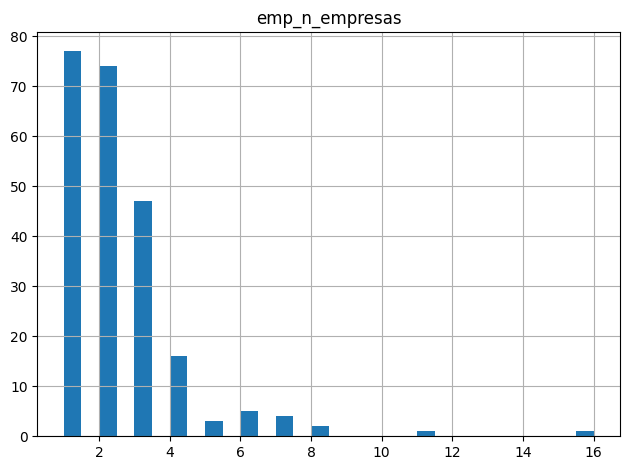

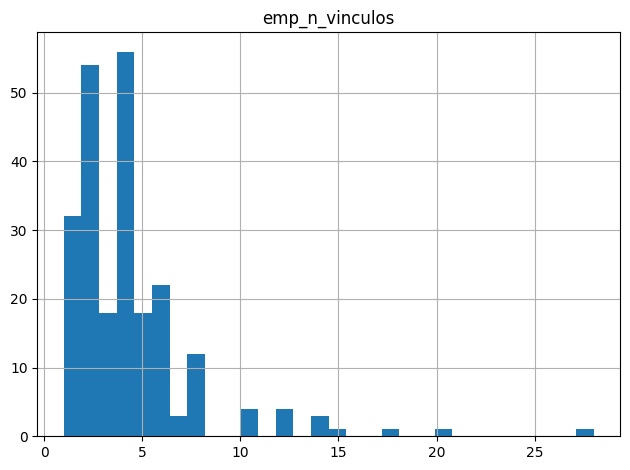

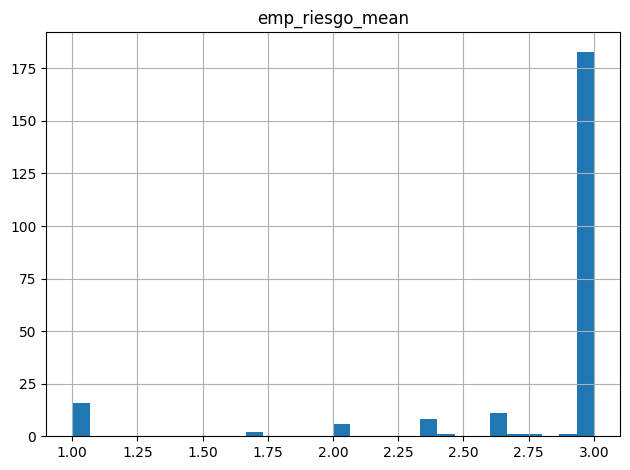

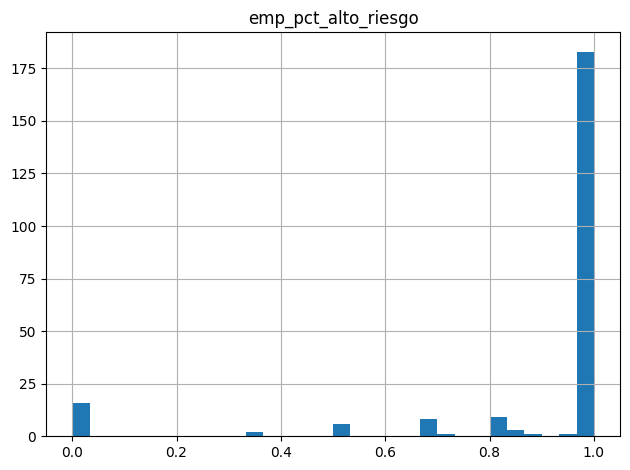

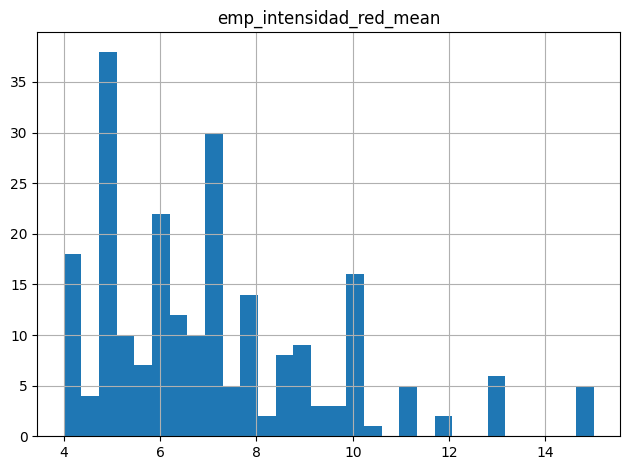

In [12]:
print("Shape:", empresa_por_obra.shape)

display(empresa_por_obra.describe().T)

if plt is not None:
    cols_plot = [
        "emp_n_empresas",
        "emp_n_vinculos",
        "emp_riesgo_mean",
        "emp_pct_alto_riesgo",
        "emp_intensidad_red_mean",
    ]

    for col in cols_plot:
        if col in empresa_por_obra.columns:
            ax = empresa_por_obra[col].hist(bins=30)
            ax.set_title(col)
            plt.tight_layout()
            plt.show()


## 11. Guardado de salidas

In [13]:
path_features_obra = DATA_PROC / "dataset_empresa_v4_features_por_obra.parquet"
path_features_obra_csv = DATA_PROC / "dataset_empresa_v4_features_por_obra.csv"

path_vinculo_auditoria = DATA_PROC / "dataset_empresa_v4_vinculo_auditoria.parquet"
path_unico_auditoria = DATA_PROC / "dataset_empresa_v4_unico_auditoria.parquet"

path_meta = DATA_PROC / "dataset_empresa_v4_meta.json"

empresa_por_obra.to_parquet(path_features_obra, index=False)
empresa_por_obra.to_csv(path_features_obra_csv, index=False, encoding="utf-8-sig")

df_vinculo.to_parquet(path_vinculo_auditoria, index=False)
df_empresa_unico_auditoria.to_parquet(path_unico_auditoria, index=False)

meta = {
    "version": "v4",
    "descripcion": "Features de empresa para dataset maestro. No es dataset final de entrenamiento.",
    "unidad_salida_principal": "CODIGO_OBRA",
    "salida_principal": str(path_features_obra),
    "salidas_auxiliares": {
        "features_por_obra_csv": str(path_features_obra_csv),
        "vinculo_auditoria": str(path_vinculo_auditoria),
        "unico_auditoria": str(path_unico_auditoria),
    },
    "n_rows_features_por_obra": int(empresa_por_obra.shape[0]),
    "n_cols_features_por_obra": int(empresa_por_obra.shape[1]),
    "features_por_obra": empresa_por_obra.columns.tolist(),
    "restricciones_modelado": [
        "RUC y nombres se conservan solo en archivos de auditoria.",
        "La salida principal no debe usarse como target, sino como input del dataset maestro.",
        "CODIGO_OBRA se usa únicamente como llave temporal de integración.",
    ],
    "riesgos": [
        "El riesgo de empresa es proxy, no etiqueta oficial.",
        "Debe evitarse usar RUC o nombres como variables predictoras.",
        "El dataset final de entrenamiento será el dataset maestro.",
    ],
}

path_meta.write_text(
    json.dumps(meta, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Guardado features por obra:", path_features_obra)
print("Guardado features por obra CSV:", path_features_obra_csv)
print("Guardado vínculo auditoría:", path_vinculo_auditoria)
print("Guardado único auditoría:", path_unico_auditoria)
print("Guardado metadata:", path_meta)


Guardado features por obra: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v4_features_por_obra.parquet
Guardado features por obra CSV: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v4_features_por_obra.csv
Guardado vínculo auditoría: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v4_vinculo_auditoria.parquet
Guardado único auditoría: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v4_unico_auditoria.parquet
Guardado metadata: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v4_meta.json


## Conclusiones

- El dataset de empresa no se entrena directamente.
- Su objetivo es generar features agregadas por obra para el dataset maestro.
- RUC, nombres y contrapartes quedan restringidos a trazabilidad y auditoría.
- La salida oficial para el dataset maestro es:

```text
data/processed/dataset_empresa_v4_features_por_obra.parquet
```

- El modelo final debe entrenarse únicamente sobre el dataset maestro, excluyendo llaves e identificadores como features.
